# Precio y recepción en Steam: ¿en qué géneros debería priorizar due diligence un fondo de inversión?

**Conclusión principal:** en los 10 géneros de juego reales del catálogo de Steam, la franja de
precio más barata (≤3,25 USD ajustados por inflación) es sistemáticamente la de peor recepción de
reseñas. La mejor recepción se concentra en precios medios-altos (6,46–12,36 USD o más), nunca en
el extremo barato. **Adventure, Indie y Casual** combinan el mejor efecto, volumen de evidencia y
recepción absoluta, y quedan como los candidatos con mejor evidencia para priorizar due diligence.

*Caso de estudio de portafolio — Analista de Datos. Autor: Juanes.*


## 1. Contexto: problema de negocio y pregunta analítica

**Cliente ficticio:** un fondo de inversión evaluando entrada en el sector de videojuegos, usando
el mercado de Steam como proxy del mercado de PC/digital.

**Problema de negocio:** el fondo no tiene un criterio basado en datos para decidir en qué género
priorizar su tesis de inversión en el mercado de PC/Steam.

**Pregunta analítica (SMART):** ¿Qué combinaciones de género y franja de precio (cuartiles de
precio ajustado por inflación, calculados sobre juegos de pago con ≥500 reseñas) en el catálogo
histórico de Steam muestran el patrón más consistente de alto % de reseñas positivas, controlando
por antigüedad del juego?

**Decisión que habilita:** recomendar 2-3 géneros donde el comité debería priorizar due diligence
de inversión, con evidencia de qué franja de precio sostiene mejor recepción en cada uno.

**Fuera de alcance:** solo PC/Steam (no consolas/móvil); F2P queda fuera del análisis de franja de
precio; no establece causalidad, solo patrón descriptivo; no asigna presupuesto de inversión;
excluye la cola larga con <500 reseñas.


## 2. Fuentes y limitaciones

| Fuente | Detalle | Licencia |
|---|---|---|
| Steam Games Dataset (fronkongames, Kaggle) | 125.855 juegos, catálogo histórico completo | CC BY 4.0 |
| CPI-U (BLS, serie `CUUR0000SA0`) | Índice de inflación EE. UU. 1997-2026, para ajustar precios | Dominio público |

**Evaluación ROCCC:** Steam Games Dataset falla parcialmente en *Original* (agregador de tercera
parte, no Valve directo) y en la confiabilidad de `estimated_owners` (estimación de SteamSpy, no
ventas reales). CPI-U no falla ninguna letra.

**Sesgos declarados:**
- **Supervivencia:** el dataset solo contiene juegos que llegaron a publicarse en Steam.
- **Cola larga:** 34,1% de los juegos tiene 0 reseñas; el filtro ≥500 reseñas los excluye
  deliberadamente — la muestra final queda sesgada hacia juegos exitosos/visibles.
- **`estimated_owners`** en rangos categóricos, no cifra confirmada — no se usa como métrica
  principal.
- **Multi-género:** 6,69% de los juegos no tiene género asignado (se excluyen, no son
  clasificables); el resto tiene entre 1 y 19 géneros por juego.

**Licencia y accesibilidad:** el crudo (~400 MB) no se sube al repo público; el README enlaza a
Kaggle. Sin PII en ninguna de las dos fuentes.


## 3. Carga y exploración inicial

Rutina estándar de exploración: forma, tipos, nulos, unicidad de clave, rangos. Esto alimenta
directamente la ficha de fuente y la prueba de integridad inicial.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Raiz del caso, resuelta en tiempo de ejecucion: el notebook vive en notebooks/,
# asi que subimos un nivel. Corre igual en cualquier maquina.
RUTA_BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUTA_CRUDO = f'{RUTA_BASE}/datos/crudos/steam_fronkongames_catalogo-historico_2026-07-28.csv'

# Cabecera cruda tiene un bug conocido: 'DiscountDLC count' fusiona dos columnas.
header_crudo = pd.read_csv(RUTA_CRUDO, nrows=0).columns.tolist()
print('Columnas declaradas en la cabecera cruda:', len(header_crudo))
print('Bug de cabecera presente:', 'DiscountDLC count' in header_crudo)

**Interpretación:** la cabecera cruda solo declara 39 columnas, pero cada fila trae 40 campos
reales porque `DiscountDLC count` fusiona `Discount` y `DLC count`. Esto se corrige antes de poder
explorar el archivo con confianza (ver fase 4 de limpieza más abajo).


## 4. Limpieza (fase 3)

El proceso completo, reproducible desde el crudo, vive en `notebooks/procesar.py` (ejecutado de
punta a punta con `assert` de reconciliación). Aquí se resumen las 8 transformaciones, cada una ya
documentada con su decisión en `bitacora-limpieza.md`:

1. **Corrección del bug de cabecera** (`DiscountDLC count` → `Discount` + `DLC count`).
2. **Exclusión de 2 juegos con fecha de lanzamiento futura.**
3. **15 columnas descartadas** por estar fuera de alcance (nulos altos o texto no estructurado).
4. **0 duplicados por `AppID`** (reconfirmado).
5. **Exclusión de 8.423 juegos sin género asignado** — no clasificables en género × precio, que es
   el corazón de la pregunta.
6. **Enriquecimiento con CPI-U (BLS):** `anio_lanzamiento`, `antiguedad_anios`,
   `precio_ajustado_usd` (año base 2026 — limitación declarada: CPI 2026 es un promedio parcial de
   solo 4 meses).
7. **Cálculo de `pct_resenas_positivas`** (`NaN`, no 0%, para los juegos sin ninguna reseña).
8. **Dataset derivado explotado por género** (`steam_juegos_por_genero.csv`): un juego con N
   géneros genera N filas — decisión confirmada con el usuario para que cada género reciba su
   propia evidencia.

**Reconciliación de conteos:** 125.855 inicial − 2 (fecha futura) − 0 (duplicados) − 8.423 (sin
género) = **117.430 final**, verificado con `assert` en `procesar.py`. El dataset explotado por
género tiene 338.575 filas juego-género.

**Valores atípicos investigados:** `DLC count` máximo de 3.703 (Fantasy Grounds VTT — verificado
como real, no se elimina). `Metacritic score` usa `0` como centinela de "sin dato" (documentado).


In [ ]:
df_limpio = pd.read_csv(f'{RUTA_BASE}/datos/limpios/steam_juegos_limpios.csv', low_memory=False)
df_genero  = pd.read_csv(f'{RUTA_BASE}/datos/limpios/steam_juegos_por_genero.csv', low_memory=False)
print('Dataset limpio (1 fila = 1 juego):', df_limpio.shape)
print('Dataset explotado por genero (1 fila = 1 juego x genero):', df_genero.shape)
assert df_limpio['AppID'].is_unique, 'AppID dejo de ser unico tras la limpieza'
print('Verificacion: AppID es clave unica en el dataset limpio -> OK')

## 5. Análisis (fase 4)

**Decisión de alcance confirmada con el usuario antes de tabular:** la columna `Genres` de Steam
mezcla géneros de juego reales con descriptores de contenido (`Violent`, `Gore`, `Nudity`,
`Sexual Content`), etiquetas de software no-juego (17 valores: `Utilities`, `Education`,
`Accounting`, `Movie`, etc.) y modelo de negocio/estado (`Free To Play`, `Early Access`). Se
excluyeron del análisis género × precio, dejando **10 géneros de juego reales**.


In [3]:

NO_GENERO_CONTENIDO = ['Violent', 'Gore', 'Nudity', 'Sexual Content']
NO_GENERO_SOFTWARE = ['Utilities', 'Design & Illustration', 'Animation & Modeling', 'Education',
                      'Video Production', 'Game Development', 'Audio Production',
                      'Software Training', 'Photo Editing', 'Web Publishing', 'Accounting',
                      'Movie', 'Documentary', 'Episodic', 'Short', 'Tutorial', '360 Video']
NO_GENERO_MODELO = ['Free To Play', 'Early Access']
EXCLUIR = set(NO_GENERO_CONTENIDO + NO_GENERO_SOFTWARE + NO_GENERO_MODELO)

n_antes = len(df_genero)
df_gen_real = df_genero[~df_genero['Genres'].isin(EXCLUIR)].copy()
print(f'Filas juego-genero antes: {n_antes} | despues de excluir no-generos: {len(df_gen_real)}')
print(f'Generos reales resultantes ({df_gen_real["Genres"].nunique()}):', sorted(df_gen_real['Genres'].unique()))


Filas juego-genero antes: 338575 | despues de excluir no-generos: 309474
Generos reales resultantes (10): ['Action', 'Adventure', 'Casual', 'Indie', 'Massively Multiplayer', 'RPG', 'Racing', 'Simulation', 'Sports', 'Strategy']


**Estadística descriptiva** (base `steam_juegos_limpios`, 117.430 juegos): precio ajustado
con media 5,89 USD y mediana 3,13 USD (asimetría a la derecha); % de reseñas positivas con media
75,83% y mediana 81,82% (82.841 juegos con ≥1 reseña); antigüedad con mediana 4 años.


In [4]:

df_limpio['total_resenas'] = df_limpio['Positive'] + df_limpio['Negative']
print(df_limpio['precio_ajustado_usd'].describe().round(2))
print()
print(df_limpio['pct_resenas_positivas'].describe().round(2))


count    117430.00
mean          5.89
std          14.52
min           0.00
25%           1.01
50%           3.13
75%           6.84
max        1284.88
Name: precio_ajustado_usd, dtype: float64

count    82841.00
mean        75.83
std         23.87
min          0.00
25%         65.00
50%         81.82
75%         94.44
max        100.00
Name: pct_resenas_positivas, dtype: float64


**Base de análisis:** filtro pago (`Price > 0`) + ≥500 reseñas, aplicado sobre el dataset
explotado por género real. Los cuartiles de `precio_ajustado_usd` se calculan sobre la base de
juegos únicos que pasan el filtro (9.048 juegos), no sobre las filas duplicadas por género, para
no inflar el cálculo de cuartiles.


In [5]:

base_precio = df_limpio[(df_limpio['Price'] > 0) & (df_limpio['total_resenas'] >= 500)].copy()
cuartiles = base_precio['precio_ajustado_usd'].quantile([0.25, 0.5, 0.75]).round(2)
print('Juegos en la base de calculo de cuartiles:', len(base_precio))
print('Cuartiles de precio_ajustado_usd:', cuartiles.to_dict())

q1, q2, q3 = cuartiles[0.25], cuartiles[0.5], cuartiles[0.75]
bordes = [-np.inf, q1, q2, q3, np.inf]
etiquetas = [f'Q1 (<= {q1})', f'Q2 ({q1}-{q2})', f'Q3 ({q2}-{q3})', f'Q4 (> {q3})']

df_gen_real['total_resenas'] = df_gen_real['Positive'] + df_gen_real['Negative']
base_analisis = df_gen_real[(df_gen_real['Price'] > 0) & (df_gen_real['total_resenas'] >= 500)].copy()
base_analisis['franja_precio'] = pd.cut(base_analisis['precio_ajustado_usd'], bins=bordes, labels=etiquetas)
print('Filas juego-genero en la base de analisis:', len(base_analisis), '| juegos unicos:', base_analisis['AppID'].nunique())


Juegos en la base de calculo de cuartiles: 9048
Cuartiles de precio_ajustado_usd: {0.25: 3.25, 0.5: 6.46, 0.75: 12.36}
Filas juego-genero en la base de analisis: 23822 | juegos unicos: 8998


**Tabla género × franja de precio** (mediana de % de reseñas positivas). Se reportan solo
celdas con n≥20 para evitar conclusiones sobre muestras chicas.


In [6]:

tabla = (base_analisis.groupby(['Genres', 'franja_precio'], observed=True)
         .agg(n=('AppID', 'count'), mediana_pct=('pct_resenas_positivas', 'median'))
         .round(2).reset_index())
tabla_robusta = tabla[tabla['n'] >= 20].sort_values(['Genres', 'franja_precio'])
print(tabla_robusta.to_string(index=False))


               Genres   franja_precio    n  mediana_pct
               Action    Q1 (<= 3.25) 1021        82.33
               Action  Q2 (3.25-6.46) 1090        85.46
               Action Q3 (6.46-12.36) 1076        86.64
               Action    Q4 (> 12.36) 1088        84.38
            Adventure    Q1 (<= 3.25) 1001        82.43
            Adventure  Q2 (3.25-6.46) 1053        86.78
            Adventure Q3 (6.46-12.36) 1046        87.47
            Adventure    Q4 (> 12.36)  930        87.48
               Casual    Q1 (<= 3.25)  855        86.27
               Casual  Q2 (3.25-6.46)  557        88.80
               Casual Q3 (6.46-12.36)  469        89.58
               Casual    Q4 (> 12.36)  349        89.28
                Indie    Q1 (<= 3.25) 1648        84.23
                Indie  Q2 (3.25-6.46) 1474        87.30
                Indie Q3 (6.46-12.36) 1334        88.17
                Indie    Q4 (> 12.36) 1105        87.08
Massively Multiplayer    Q1 (<= 3.25)   51      

**Interpretación:** en los 10 géneros, la franja Q1 (más barata) tiene siempre la mediana más
baja o empatada-más-baja de % de reseñas positivas. La mejor recepción está en Q3 o Q4 según el
género — nunca en Q1 o Q2.


### Verificaciones antes de creer el resultado

1. **Sensatez:** los cuartiles ajustados (3,25 / 6,46 / 12,36 USD) están en el mismo orden de
   magnitud que los cuartiles del precio de lista bruto sin ajustar (2,49 / 4,99 / 9,99 USD) —
   plausible para un catálogo indie/AA de Steam.
2. **Recálculo por vía alterna:** la tabla se recalculó con `pivot_table` en vez de `groupby.agg`
   y coincide punto por punto.
3. **Antigüedad como posible confusor:** la correlación entre `antiguedad_anios` y
   `pct_resenas_positivas` es de solo −0,087 — prácticamente nula.


In [7]:

corr = base_analisis[['antiguedad_anios', 'pct_resenas_positivas', 'precio_ajustado_usd']].corr()
print(corr.round(3))
print()
print('Nota: correlacion no implica causalidad. Se usa solo para decidir si antiguedad confunde el patron precio-recepcion.')


                       antiguedad_anios  ...  precio_ajustado_usd
antiguedad_anios                  1.000  ...               -0.226
pct_resenas_positivas            -0.087  ...                0.002
precio_ajustado_usd              -0.226  ...                1.000

[3 rows x 3 columns]

Nota: correlacion no implica causalidad. Se usa solo para decidir si antiguedad confunde el patron precio-recepcion.


4. **Control por antigüedad:** se repite la tabla separando juegos recientes (≤ mediana de
   antigüedad) de viejos. El patrón "Q1 es la peor franja" se sostiene en ambas bandas — no es un
   artefacto de que los juegos baratos sean simplemente más viejos (ver figura 4 más abajo).
5. **Efecto de tamaño cuantificado:** la diferencia entre Q1 y la mejor franja va de 2,50 p.p.
   (RPG) a 5,04 p.p. (Adventure) — real pero moderada, no "el precio duplica la recepción".
6. **Recálculo manual** de `pct_resenas_positivas` sobre una muestra al azar, contra la fórmula
   `Positive/(Positive+Negative)×100` — coincide exacto.
7. **Robustez de muestra:** n por género va de 176 (Massively Multiplayer) a 5.561 (Indie). Los
   géneros con n<350 se reportan con advertencia de muestra chica.


### Hallazgos de la fase 4

1. La franja más barata (Q1) es sistemáticamente la de peor recepción en los 10 géneros.
2. La mejor recepción se concentra en Q3/Q4, nunca en Q1 o Q2.
3. El efecto es moderado y consistente (2,50–5,04 p.p.), no dramático.
4. **Adventure, Indie y Casual** combinan la mejor evidencia combinada (efecto + volumen +
   recepción absoluta).
5. **Massively Multiplayer** es un caso aparte: patrón no monótono y muestra chica (n=176) —
   evidencia débil, no se descarta ni se recomienda con la evidencia actual.

### Lo que los datos no responden

- No hay reseñas fechadas individuales — la antigüedad es un proxy, no la evolución real de
  reseñas en el tiempo.
- No establece causalidad: puede reflejar selección (estudios que cobran más también invierten más
  en calidad), no que subir el precio mejore la recepción.
- No cubre la cola larga (<500 reseñas, 34,1% del catálogo con 0 reseñas).
- Massively Multiplayer tiene evidencia insuficiente para una recomendación firme por sí solo.


## 6. Visualizaciones (fase 5)

Cuatro figuras (spotlighting: de los cinco hallazgos, estas son las que sostienen el argumento
frente al comité de inversión). Cada una sigue el método McCandless: titular = hallazgo, eje de
barras desde cero, un color protagonista y gris de contexto, orden por valor, nota de fuente.


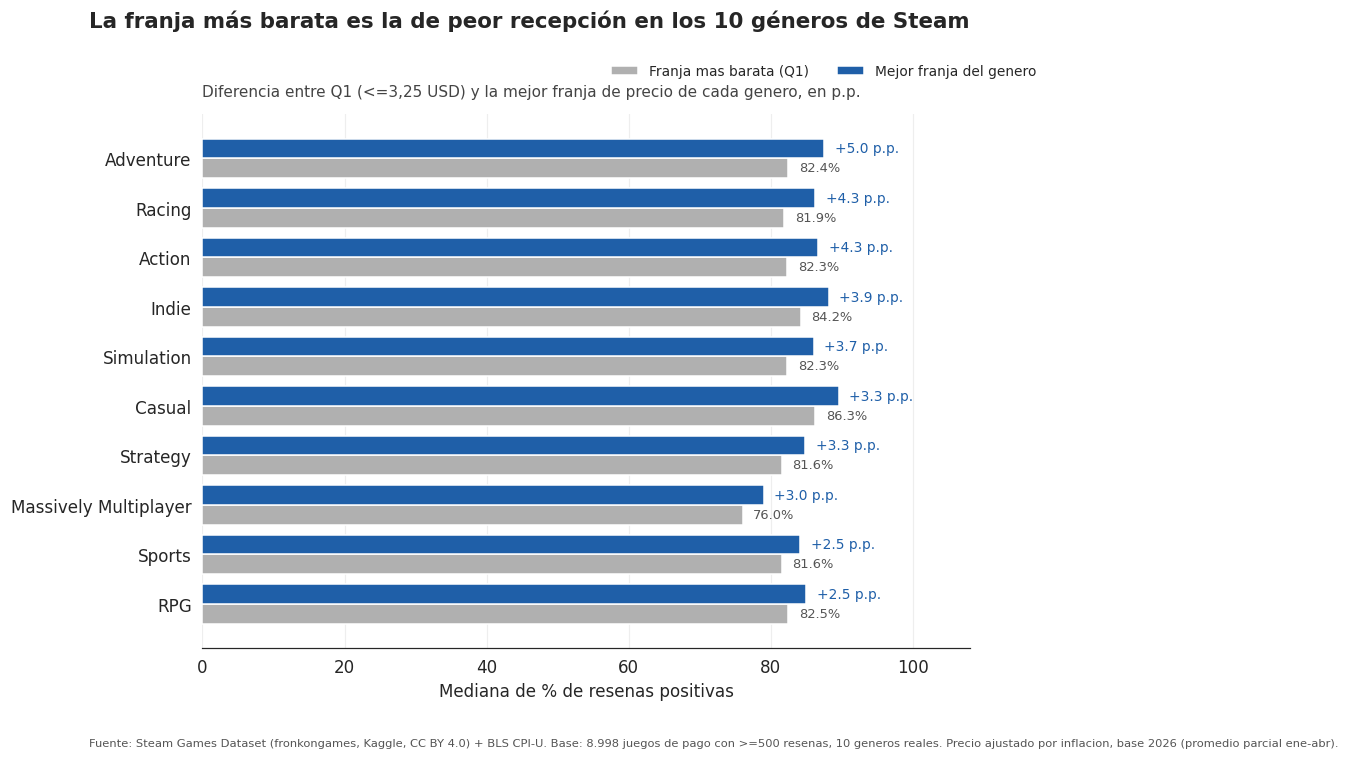

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
plt.rcParams['font.size'] = 11
GRIS, AZUL = '#b0b0b0', '#1f5fa8'

FUENTE = ('Fuente: Steam Games Dataset (fronkongames, Kaggle, CC BY 4.0) + BLS CPI-U. '
          'Base: 8.998 juegos de pago con >=500 resenas, 10 generos reales. '
          'Precio ajustado por inflacion, base 2026 (promedio parcial ene-abr).')

filas = []
for genero, sub in tabla_robusta.groupby('Genres'):
    q1v = sub.loc[sub['franja_precio'] == etiquetas[0], 'mediana_pct']
    if q1v.empty:
        continue
    q1v = q1v.iloc[0]
    mejor = sub.loc[sub['mediana_pct'].idxmax()]
    filas.append(dict(Genres=genero, Q1=q1v, mejor=mejor['mediana_pct'], dif=mejor['mediana_pct'] - q1v))
f1 = pd.DataFrame(filas).sort_values('dif', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6.3))
y = np.arange(len(f1))
ax.barh(y - 0.2, f1['Q1'], height=0.4, color=GRIS, label='Franja mas barata (Q1)')
ax.barh(y + 0.2, f1['mejor'], height=0.4, color=AZUL, label='Mejor franja del genero')
ax.set_yticks(y); ax.set_yticklabels(f1['Genres']); ax.set_xlim(0, 108)
ax.set_xlabel('Mediana de % de resenas positivas')
fig.suptitle('La franja más barata es la de peor recepción en los 10 géneros de Steam',
             fontsize=14, weight='bold', x=0.01, ha='left', y=1.03)
ax.set_title('Diferencia entre Q1 (<=3,25 USD) y la mejor franja de precio de cada genero, en p.p.',
             fontsize=10, color='#444444', loc='left', pad=12)
for i, row in enumerate(f1.itertuples()):
    ax.text(row.mejor + 1.5, i + 0.2, f'+{row.dif:.1f} p.p.', va='center', fontsize=9, color=AZUL)
    ax.text(row.Q1 + 1.5, i - 0.2, f'{row.Q1:.1f}%', va='center', fontsize=8.5, color='#555555')
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.97), ncol=2, frameon=False, fontsize=9)
sns.despine(left=True); ax.grid(axis='x', color='#eeeeee')
fig.text(0.01, -0.02, FUENTE, ha='left', va='top', fontsize=7.5, color='#555555')
plt.show()


**Figura 1 — texto alternativo:** barras horizontales por género comparando la mediana de % de reseñas positivas en Q1 contra la mejor franja de precio; en los 10 géneros la barra azul (mejor franja) supera a la gris (Q1), con diferencias de 2,5 a 5,0 puntos porcentuales.

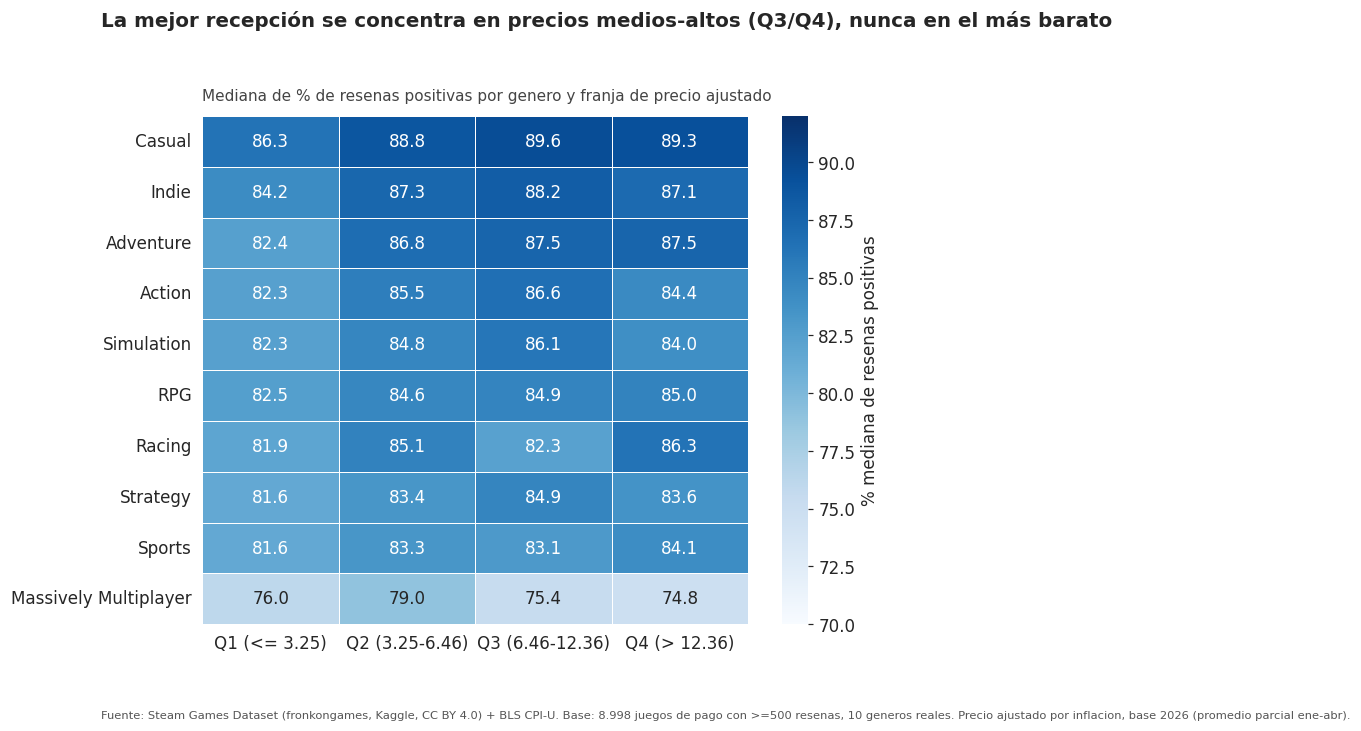

In [9]:

pivot = tabla_robusta.pivot(index='Genres', columns='franja_precio', values='mediana_pct')
orden = pivot.mean(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[orden]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% mediana de resenas positivas'},
            linewidths=0.5, linecolor='white', ax=ax, vmin=70, vmax=92)
fig.suptitle('La mejor recepción se concentra en precios medios-altos (Q3/Q4), nunca en el más barato',
             fontsize=13, weight='bold', x=0.01, ha='left', y=1.04)
ax.set_title('Mediana de % de resenas positivas por genero y franja de precio ajustado',
             fontsize=10, color='#444444', loc='left', pad=10)
ax.set_xlabel(''); ax.set_ylabel('')
fig.text(0.01, -0.02, FUENTE, ha='left', va='top', fontsize=7.5, color='#555555')
plt.show()


**Figura 2 — texto alternativo:** mapa de calor género (filas) × franja de precio (columnas) con la mediana de % de reseñas positivas; las columnas Q3 y Q4 son visiblemente más oscuras (mayor %) que Q1 en casi todos los géneros.

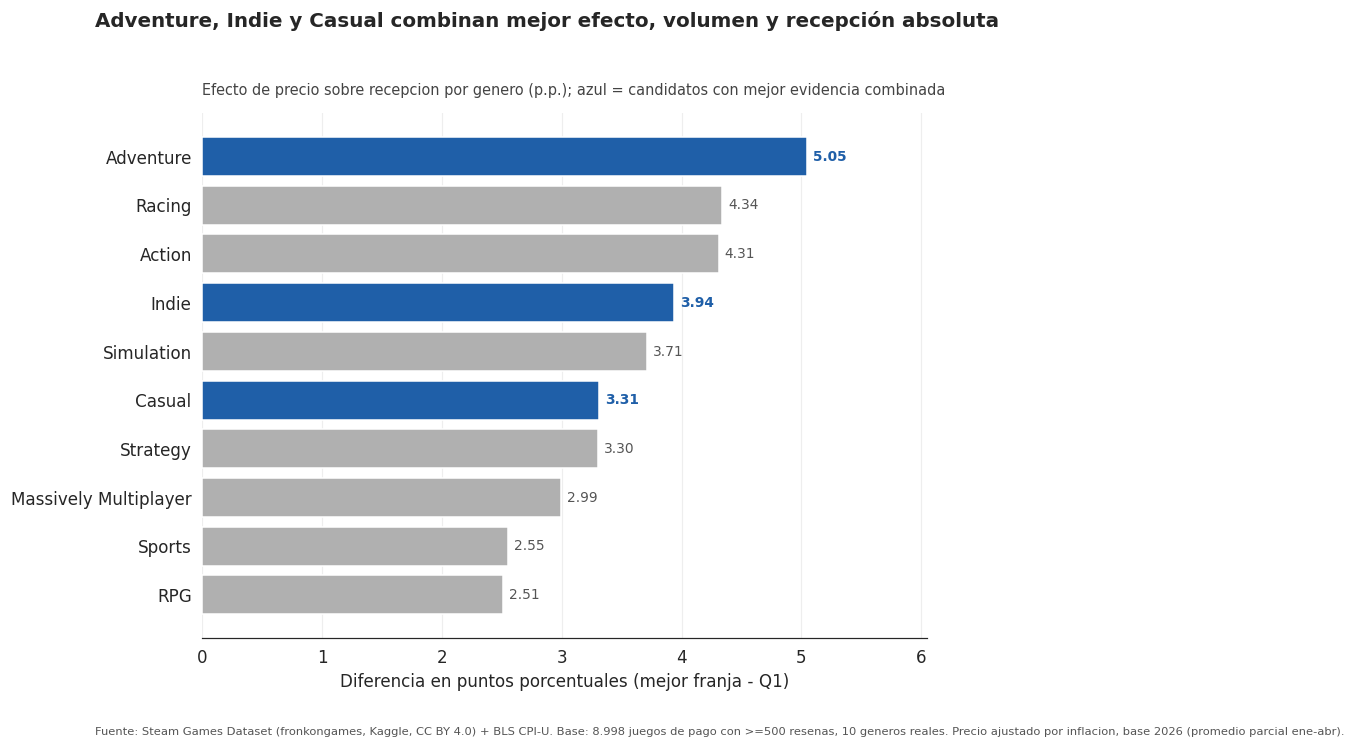

In [10]:

CANDIDATOS = {'Adventure', 'Indie', 'Casual'}
f3 = f1.sort_values('dif', ascending=True).copy()
colores = [AZUL if g in CANDIDATOS else GRIS for g in f3['Genres']]
fig, ax = plt.subplots(figsize=(8.5, 6.2))
y = np.arange(len(f3))
ax.barh(y, f3['dif'], color=colores)
ax.set_yticks(y); ax.set_yticklabels(f3['Genres'])
ax.set_xlabel('Diferencia en puntos porcentuales (mejor franja - Q1)')
fig.suptitle('Adventure, Indie y Casual combinan mejor efecto, volumen y recepción absoluta',
             fontsize=13, weight='bold', x=0.01, ha='left', y=1.03)
ax.set_title('Efecto de precio sobre recepcion por genero (p.p.); azul = candidatos con mejor evidencia combinada',
             fontsize=9.5, color='#444444', loc='left', pad=12)
for i, row in enumerate(f3.itertuples()):
    ax.text(row.dif + 0.05, i, f'{row.dif:.2f}', va='center', fontsize=9,
            color=AZUL if row.Genres in CANDIDATOS else '#555555',
            weight='bold' if row.Genres in CANDIDATOS else 'normal')
ax.set_xlim(0, f3['dif'].max() + 1)
sns.despine(left=True); ax.grid(axis='x', color='#eeeeee')
fig.text(0.01, -0.02, FUENTE, ha='left', va='top', fontsize=7.5, color='#555555')
plt.show()


**Figura 3 — texto alternativo:** ranking de barras horizontales del efecto de precio (diferencia en p.p. entre la mejor franja y Q1) por género, ordenado de mayor a menor; Adventure, Indie y Casual están resaltados en azul como candidatos, el resto en gris.

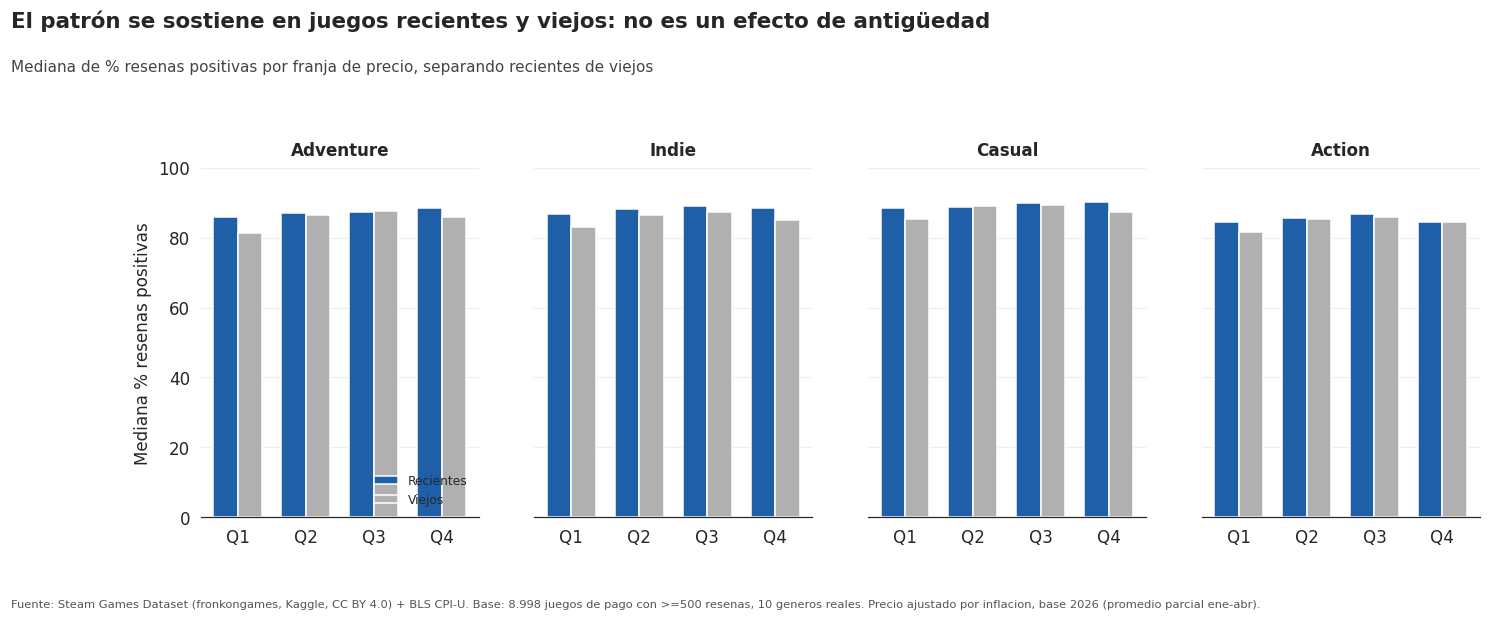

In [11]:

mediana_antig = base_analisis['antiguedad_anios'].median()
base_analisis['banda'] = np.where(base_analisis['antiguedad_anios'] <= mediana_antig, 'Recientes', 'Viejos')
generos4 = ['Adventure', 'Indie', 'Casual', 'Action']
sub4 = base_analisis[base_analisis['Genres'].isin(generos4)]
tabla4 = (sub4.groupby(['Genres', 'banda', 'franja_precio'], observed=True)
          .agg(n=('AppID', 'count'), mediana_pct=('pct_resenas_positivas', 'median')).reset_index())
tabla4 = tabla4[tabla4['n'] >= 20]

fig, axes = plt.subplots(1, 4, figsize=(15, 5.3), sharey=True)
fig.subplots_adjust(top=0.72, bottom=0.12)
for ax, genero in zip(axes, generos4):
    d = tabla4[tabla4['Genres'] == genero]
    for banda, color, offset in [('Recientes', AZUL, -0.18), ('Viejos', GRIS, 0.18)]:
        dd = d[d['banda'] == banda].set_index('franja_precio').reindex(etiquetas)
        x = np.arange(len(etiquetas)) + offset
        ax.bar(x, dd['mediana_pct'], width=0.36, color=color, label=banda)
    ax.set_xticks(np.arange(len(etiquetas))); ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.set_title(genero, fontsize=11, weight='bold', pad=8)
    ax.set_ylim(0, 100)
    sns.despine(ax=ax, left=True); ax.grid(axis='y', color='#eeeeee')
axes[0].set_ylabel('Mediana % resenas positivas')
axes[0].legend(loc='lower right', frameon=False, fontsize=8)
fig.suptitle('El patrón se sostiene en juegos recientes y viejos: no es un efecto de antigüedad',
             fontsize=14, weight='bold', x=0.01, ha='left', y=0.99)
fig.text(0.01, 0.885, 'Mediana de % resenas positivas por franja de precio, separando recientes de viejos',
         fontsize=10, color='#444444')
fig.text(0.01, -0.02, FUENTE, ha='left', va='top', fontsize=7.5, color='#555555')
plt.show()


**Figura 4 — texto alternativo:** cuatro paneles de barras agrupadas (Adventure, Indie, Casual, Action), cada uno comparando juegos recientes vs. viejos en las 4 franjas de precio; en los cuatro géneros, Q1 es la franja más baja tanto para recientes como para viejos.

## 7. Hallazgos, recomendaciones y limitaciones (fase 6)

**Pendiente** — la fase 6 (Actuar) formaliza las recomendaciones de inversión a partir de estos
hallazgos, junto con las limitaciones consolidadas y los datos adicionales deseables. Se completa
en la siguiente etapa del caso.
